In [1]:
from pathlib import Path
from functools import partial

import numpy as np

from matplotlib import pyplot as plt

from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.time import Time

from jwst import datamodels

from tqdm.auto import tqdm

In [2]:
import os
os.environ['STPSF_PATH'] = os.path.expanduser('~/.cache/stpsf-data')

import stpsf

**WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-072 DOESN'T MATCH THE CURRENT ONLINE VERSION PRDOPSSOC-073
Please consider updating pysiaf, e.g. pip install --upgrade pysiaf or conda update pysiaf


In [3]:
n6791fits = list(Path('../ngc6791_cals').glob('*.fits'))

dm0 = datamodels.open(n6791fits[0])

slit = dm0.slits[49]
scoord = SkyCoord(slit.source_ra, slit.source_dec, unit='deg')  # the ra and dec would have a delta in an inference loop so is different each time
swcs = slit.meta.wcs

assert slit.source_name == '2609_21'

The below should be replaced with ``stpsf.setup_sim_to_match_file(str(n6791fits[0]))`` once that works

In [4]:
nrs = stpsf.NIRSpec()
nrs.detector = dm0.meta.instrument.detector
nrs.filter = dm0.meta.instrument.filter
nrs.disperser = dm0.meta.instrument.grating

xdet, ydet = swcs.transform('detector', 'sca', *np.indices(slit.data.shape)[::-1])
nrs.detector_position = (np.mean(xdet), np.mean(ydet))

nrs.load_wss_opd_by_date(Time(dm0.meta.exposure.mid_time, format='mjd'))

nrs.image_mask = 'Single MSA open shutter'

iterating query, tdelta=3.0

MAST OPD query around UTC: 60136.5904089294
                        MJD: 60136.5904089294

OPD immediately preceding the given datetime:
	URI:	 mast:JWST/product/R2023071203-NRCA3_FP1-1.fits
	Date (MJD):	 60136.5363
	Delta time:	 -0.0542 days

OPD immediately following the given datetime:
	URI:	 mast:JWST/product/R2023071403-NRCA3_FP1-1.fits
	Date (MJD):	 60138.8979
	Delta time:	 2.3075 days
User requested choosing OPD time closest in time to 60136.5904089294, which is R2023071203-NRCA3_FP1-1.fits, delta time -0.054 days
Importing and format-converting OPD from /home/erik/.cache/stpsf-data/MAST_JWST_WSS_OPDs/R2023071203-NRCA3_FP1-1.fits
Backing out SI WFE and OTE field dependence at the WF sensing field point (NRCA3_FP1)


In [5]:
msa_slit_width = 0.2 #u.arcsec
msa_slit_height = 0.46 #u.arcsec

offset0_x = slit.source_xpos*msa_slit_width
offset0_y = slit.source_ypos*msa_slit_height

nrs.options.update({'source_offset_x': offset0_x, 
                    'source_offset_y': offset0_y})

# Make data

In [6]:
n = 1024
path = Path('psfarrs.npz')

if path.is_file():
    data = np.load(path)

    psfarrs = data['psfarrs']
    psfxs = data['xs']
    psfys = data['ys']

    if len(psfxs) == len(psfys) == len(psfarrs) == n:
        print('Loaded precomputed PSF array')
    else:
        print('Precomputed PSF array has wrong shape, recomputing')
        psfarrs = None

if psfarrs is None:
    psfxs = (np.random.rand(n)-0.5)*msa_slit_width
    psfys = (np.random.rand(n)-0.5)*msa_slit_height

    psfarrs = []
    for x, y in tqdm(list(zip(psfxs, psfys))):
        nrs.options.update({'source_offset_x': x, 
                            'source_offset_y': y})
        psf = nrs.calc_psf(fov_pixels=20, monochromatic=1.1e-6, oversample=8)
        psfarrs.append(psf['OVERDIST'].data)

    psfarrs = np.array(psfarrs)
    np.savez('psfarrs.npz', psfarrs=psfarrs, xs=psfxs, ys=psfys)

psfarrs.shape

Loaded precomputed PSF array


(1024, 160, 160)

# INR w/ 2d paired wavelets

## Start with the 1d for comparisons

In [7]:
import equinox as eqx
import jax
import jax.numpy as jnp
import optax

rkey = jax.random.PRNGKey(42)

jax.devices()

[CudaDevice(id=0)]

Note that the below is not batched - use vmap for that.

In [8]:
class ComplexGaborWavelet(eqx.Module):
    w0: float
    s0: float

    def __init__(self, w0=20, s0=10, trainable=True):
        if trainable:
            self.w0 = jnp.array(w0, dtype=jnp.float32)
            self.s0 = jnp.array(s0, dtype=jnp.float32)
        else:
            self.w0 = w0
            self.s0 = s0

    def __call__(self, x):
        arg1 = (1j*self.w0)*x 
        arg2 = -jnp.abs(x*self.s0)**2
        return jnp.exp(arg1 + arg2)
    
    
class SinGaborWavelet(eqx.Module):
    w0: float
    s0: float

    def __init__(self, w0=20, s0=10, trainable=True):
        if trainable:
            self.w0 = jnp.array(w0, dtype=jnp.float32)
            self.s0 = jnp.array(s0, dtype=jnp.float32)
        else:
            self.w0 = w0
            self.s0 = s0

    def __call__(self, x):
        return jnp.sin(self.w0 * x) * jnp.exp(-(x * self.s0) ** 2)
    

class CosGaborWavelet(eqx.Module):
    w0: float
    s0: float

    def __init__(self, w0=20, s0=10, trainable=True):
        if trainable:
            self.w0 = jnp.array(w0, dtype=jnp.float32)
            self.s0 = jnp.array(s0, dtype=jnp.float32)
        else:
            self.w0 = w0
            self.s0 = s0

    def __call__(self, x):
        return jnp.cos(self.w0 * x) * jnp.exp(-(x * self.s0) ** 2)


class PSFWIRE1D(eqx.Module):
    layers: list

    def __init__(self, n_in_coo,
                       hidden_size=256, 
                       num_hidden_layers=2, 
                       final_activation=jax.nn.sigmoid,
                       rkey=None,
                       complex=False,
                       w0=20, s0=10,
                       trainable_activations=False):
        if rkey is None:
            rkey = jax.random.PRNGKey(0)

        rkeys = jax.random.split(rkey, num_hidden_layers+2)

        if complex and complex!='sin':
            wavelet_activation_cls = ComplexGaborWavelet
        elif complex=='sin':
            wavelet_activation_cls = SinGaborWavelet
        else:
            wavelet_activation_cls = CosGaborWavelet
        def generate_activation():
            return wavelet_activation_cls(w0=w0, s0=s0, trainable=trainable_activations)

        layers = [eqx.nn.Linear(n_in_coo, hidden_size, key=rkeys[0]),
                  generate_activation()]
        for i in range(num_hidden_layers):
            layers.append(eqx.nn.Linear(hidden_size, hidden_size, key=rkeys[i+1]))
            layers.append(generate_activation())

        if complex:
            layers.append(jnp.real)
        layers.append(eqx.nn.Linear(hidden_size, 1, key=rkeys[-1]))
        layers.append(final_activation)

        self.layers = layers
        
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x.squeeze()  #unnecessary for the sin/cos wavelet, but necessary for the complex wavelet
    
    @property
    def n_in_coo(self):
        return self.layers[0].in_features // (self.coordinate_encoder.freqs.shape[0] * 2)

model = PSFWIRE1D(n_in_coo=4)
print(model)

x = jax.random.uniform(rkey, (10, 4))
jax.vmap(model)(x)

PSFWIRE1D(
  layers=[
    Linear(
      weight=f32[256,4],
      bias=f32[256],
      in_features=4,
      out_features=256,
      use_bias=True
    ),
    CosGaborWavelet(w0=20, s0=10),
    Linear(
      weight=f32[256,256],
      bias=f32[256],
      in_features=256,
      out_features=256,
      use_bias=True
    ),
    CosGaborWavelet(w0=20, s0=10),
    Linear(
      weight=f32[256,256],
      bias=f32[256],
      in_features=256,
      out_features=256,
      use_bias=True
    ),
    CosGaborWavelet(w0=20, s0=10),
    Linear(
      weight=f32[1,256],
      bias=f32[1],
      in_features=256,
      out_features=1,
      use_bias=True
    ),
    <PjitFunction of <function sigmoid at 0x7f25530c2400>>
  ]
)


Array([0.47788796, 0.6064395 , 0.48174834, 0.5028679 , 0.44171482,
       0.5231412 , 0.5418883 , 0.6199876 , 0.472638  , 0.5654275 ],      dtype=float32)

In [9]:
def mse_loss_fn(model, x, y):
    y_pred = jax.vmap(model)(x)
    return jnp.mean((y_pred - y)**2)

def l1_loss_fn(model, x, y):
    y_pred = jax.vmap(model)(x)
    return jnp.mean(jnp.abs(y_pred - y))

def rel_loss_fn(model, x, y, eps=1e-8):
    y_pred = jax.vmap(model)(x)
    return jnp.mean(((y_pred - y)/(y + eps))**2)

def mse_plus_log_loss_fn(model, x, y, logfrac=0.01, eps=1e-8):
    y_pred = jax.vmap(model)(x)
    mse = (y_pred - y)**2
    log_loss = (jnp.log(y_pred+eps) - jnp.log(y+eps))**2
    return jnp.mean(mse + logfrac*log_loss)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater, losslamb=0.01):
    loss, grads = eqx.filter_value_and_grad(mse_plus_log_loss_fn)(model, x, y, losslamb)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

class CoordinateNormalizer:
    def __init__(self, coord):
        self.min = jnp.min(coord)
        self.ptp = jnp.ptp(coord)

    def normalize(self, coord):
        return (coord - self.min)/self.ptp * 2 - 1
    
    def denormalize(self, norm_coord):
        return (norm_coord + 1)/2 * self.ptp + self.min


### Test with just a single psf location/2d

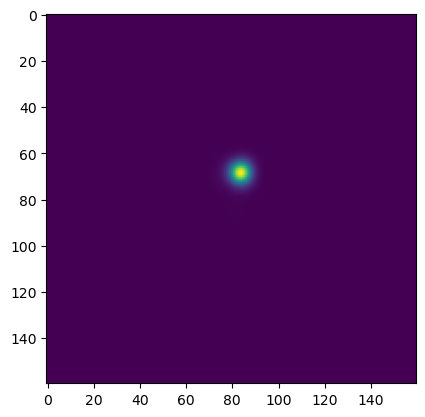

In [18]:
plt.imshow(psfarrs[512])

  0%|          | 0/15000 [00:00<?, ?it/s]

resid std: 2.7509986e-05 relative to image: 0.054681793


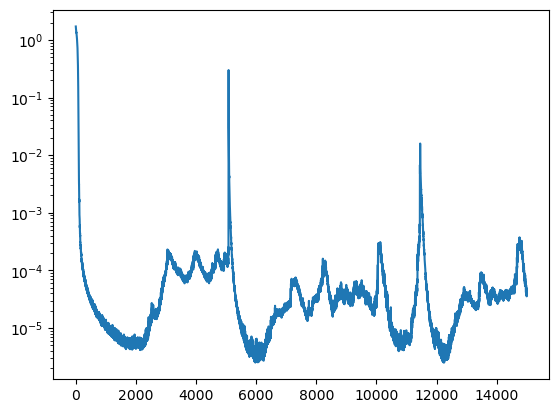

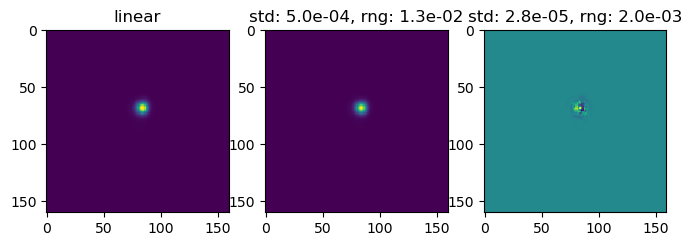

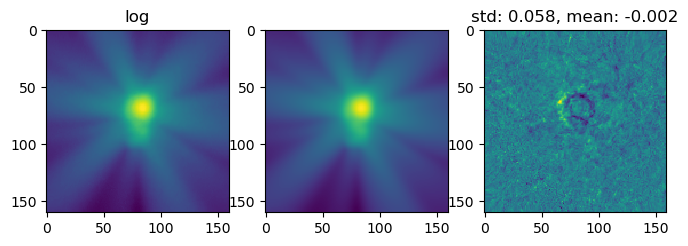

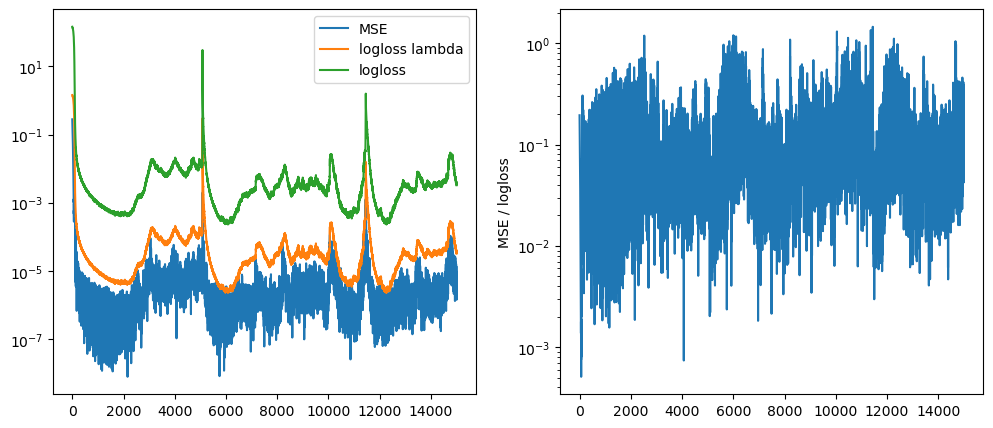

In [20]:
LEARNING_RATE = 1e-3
EPOCHS = 15000
BATCH_SIZE = 2048

LOSS_LOG_LAMBDA = 1e-2

psf = psfarrs[512] # psf is (160, 160)

xpx, ypx = jnp.indices(psfarrs.shape[1:])

xs = jnp.stack((xpx.ravel(), ypx.ravel()), axis=-1).astype(float)
xnorm = CoordinateNormalizer(xs)
xs = xnorm.normalize(xs)
ys = psf.ravel()/psf.max()


model = PSFWIRE1D(n_in_coo=2)

optimizer = optax.adam(learning_rate=LEARNING_RATE)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

mselosses = jnp.ones((EPOCHS,)) * jnp.nan
losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    mselosses = mselosses.at[i].set(mse_loss_fn(model, xi, yi))
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update, losslamb=LOSS_LOG_LAMBDA)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


pred = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])
rnpred = pred / pred.sum()
rnpsf = psf / psf.sum()
diff = rnpsf - rnpred

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(rnpred, interpolation='nearest')
ax2.imshow(rnpsf, interpolation='nearest')
ax3.imshow(diff, interpolation='nearest')

ax2.set_title(f'std: {rnpred.std():.1e}, rng: {rnpred.max()-rnpred.min():.1e}')
ax3.set_title(f'std: {diff.std():.1e}, rng: {diff.max()-diff.min():.1e}')

ax1.set_title('linear')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(jnp.log(rnpred), interpolation='nearest')
ax2.imshow(jnp.log(rnpsf), interpolation='nearest')
ldiff = jnp.log(rnpsf) - jnp.log(rnpred)
ax3.imshow(ldiff, interpolation='nearest')
ax3.set_title(f'std: {ldiff.std():.2}, mean: {ldiff.mean():.2}')
ax1.set_title('log')

print('resid std:', diff.std(), 'relative to image:', diff.std()/rnpsf.std())

# compare the different loss function compnents
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
loglossesl = losses - mselosses
loglosses = loglossesl / LOSS_LOG_LAMBDA
ax1.semilogy(mselosses, label='MSE')
ax1.semilogy(loglossesl, label='logloss lambda')
ax1.semilogy(loglosses, label='logloss')
ax1.legend(loc=0)

ax2.semilogy(mselosses/loglossesl)
ax2.set_ylabel('MSE / logloss');

In [14]:
vm = jax.jit(jax.vmap(model))
vm(xs).reshape(psfarrs.shape[1:]).block_until_ready()

%timeit vm(xs).reshape(psfarrs.shape[1:]).block_until_ready()

326 μs ± 4.15 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


### Layer inspection

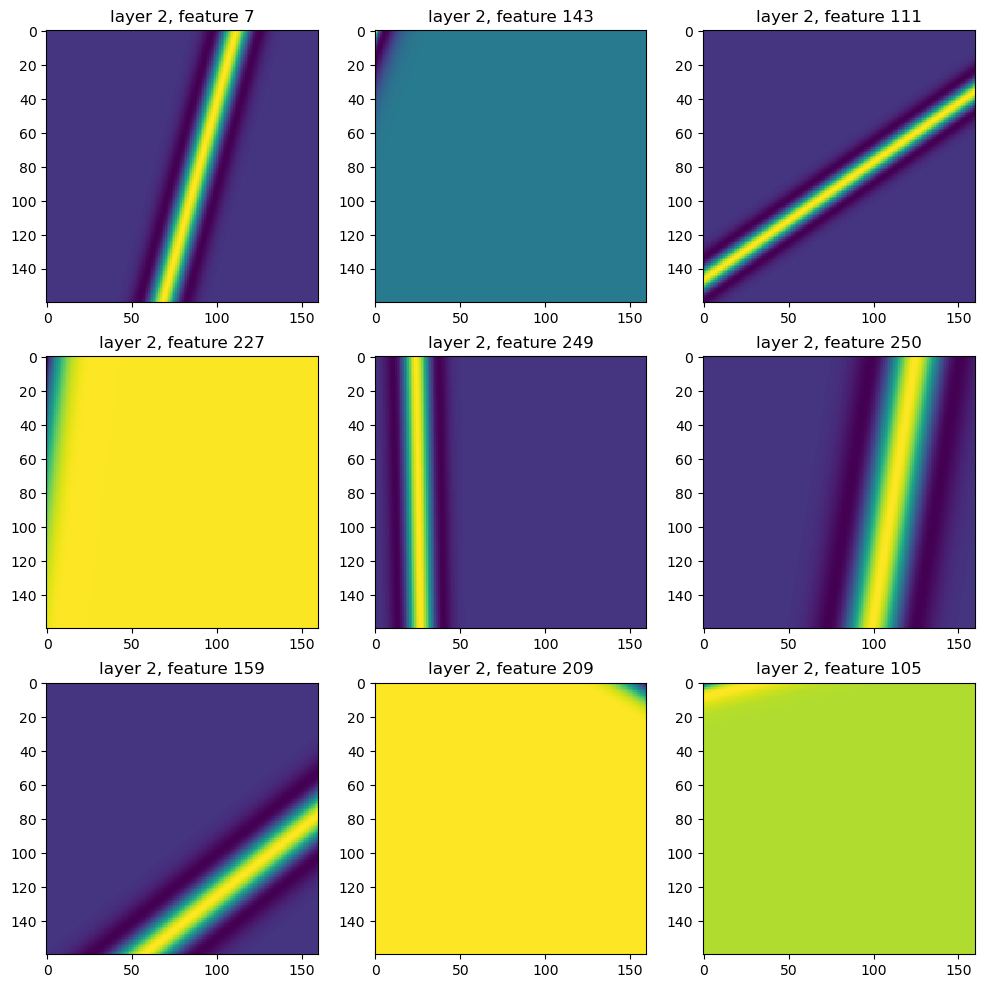

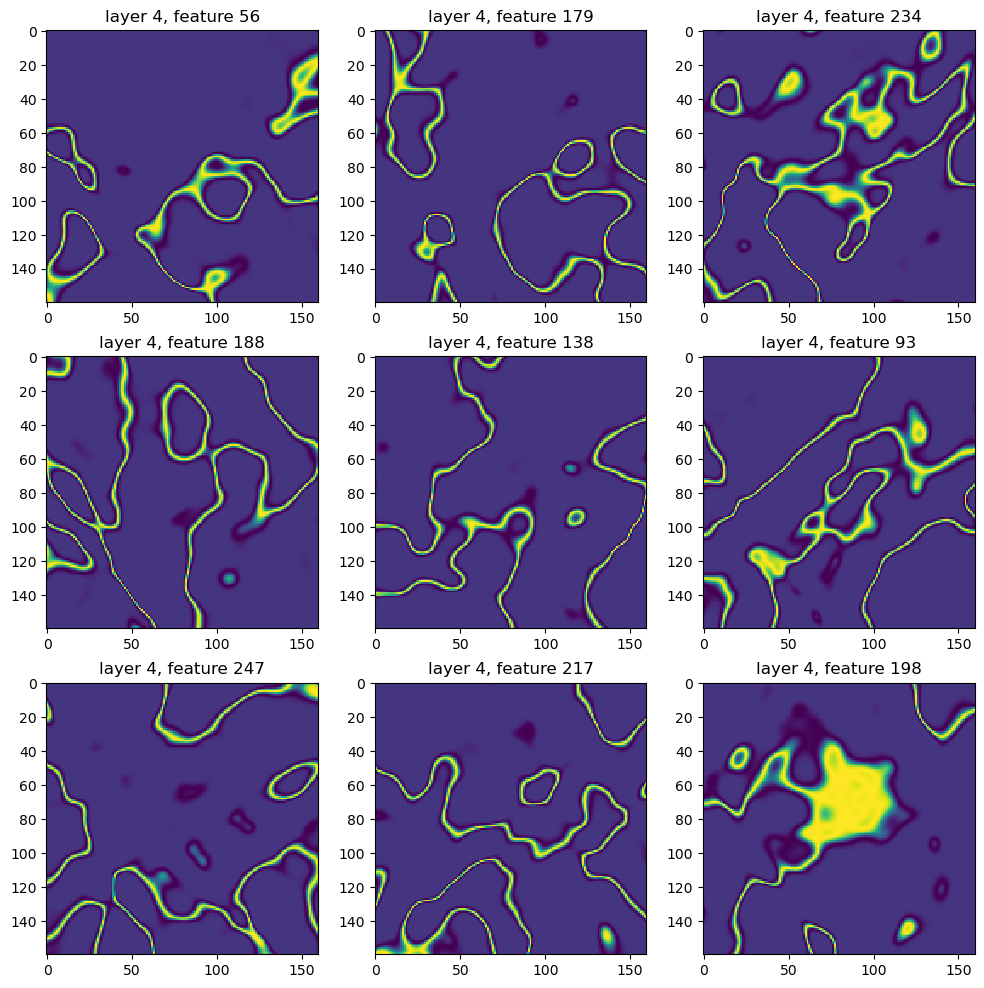

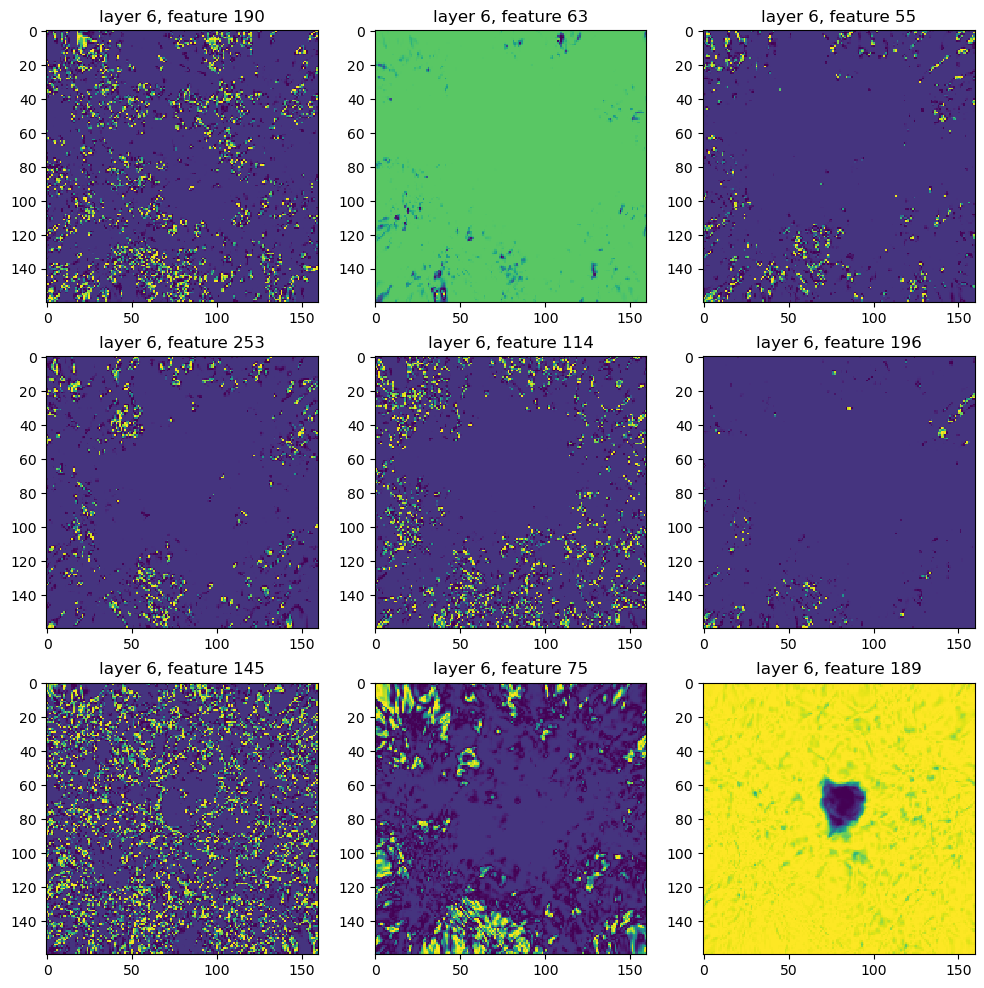

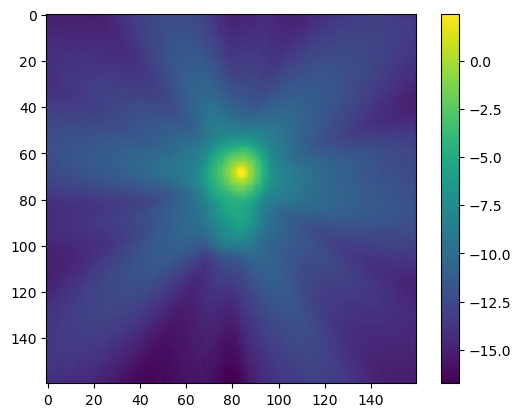

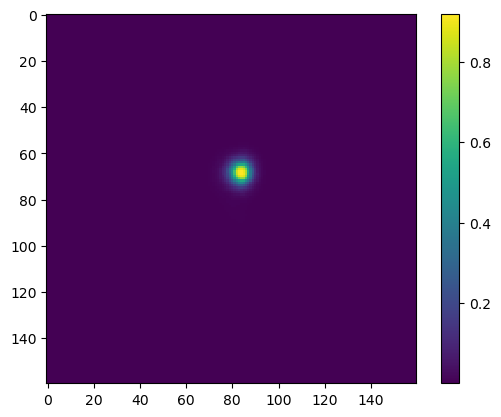

In [ ]:
def viz_layers(model, xs, axshape=(3, 3), figsize=(12, 12)):
    nl = len(model.layers)
    def eval_layers(x, n):
        for i in range(n):
            x = model.layers[i](x)
        return x
    
    for n in range(2, nl, 2):
        yl =  jax.vmap(partial(eval_layers, n=n))(xs).reshape(psfarrs.shape[1:] + (-1,))
        fig, axs = plt.subplots(*axshape, figsize=figsize)
        idxs = np.random.choice(np.arange(yl.shape[-1]), size=axs.shape, replace=False)
        for ax, idx in zip(axs.ravel(), idxs.ravel()):
            ax.imshow(yl[..., idx], interpolation='nearest')
            ax.set_title(f'layer {n}, feature {idx}')


    y1 = jax.vmap(partial(eval_layers, n=nl-1))(xs).reshape(psfarrs.shape[1:] + (-1,))

    plt.figure()
    plt.imshow(y1[..., 0], interpolation='nearest')
    plt.colorbar()

    plt.figure()
    plt.imshow(model.layers[-1](y1)[..., 0], interpolation='nearest')
    plt.colorbar()
             
viz_layers(model, xs)


### Now try the 4D version

  0%|          | 0/10000 [00:00<?, ?it/s]

E0701 18:28:12.231672  103457 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.1 = f32[131072,256]{1,0} fusion(mul.106, dynamic_nodonate__first___4_.1), kind=kCustom, calls=gemm_fusion_dot.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["128","128"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":true,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0701 18:28:12.231715  103457 xtile_compiler.cc:401] Computation: gemm_fusion_dot.1_computation.clone {
  parameter_0.1 = f32[131072,256]{1,0} parameter(0)
  parameter_1.1 = f32[256,256]{1,0} parameter(1)
  ROOT dot.14 = f32[131072,256]{1,0} dot(parameter_0.1, parameter_1.1), lhs_contracting_dims={1}, rhs_contracting_dims={1}, backend_config={"sizes":["32"]}
}
E0701 18:28:13.144423  10345

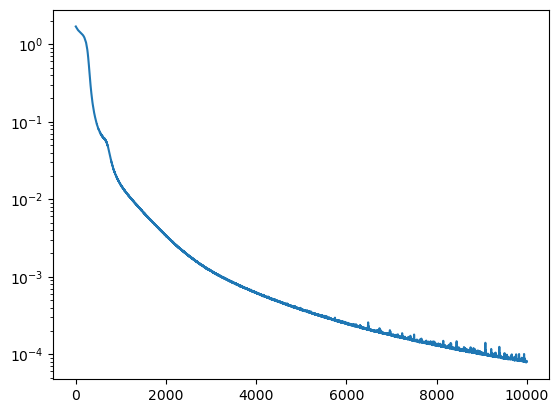

In [107]:
LEARNING_RATE = 1e-4
EPOCHS = 10000
BATCH_SIZE = 2**17

psf = psfarrs[512] # psf is (160, 160)

xpx, ypx = jnp.indices(psfarrs.shape[1:])
pxn = CoordinateNormalizer(jnp.stack((xpx, ypx)))
xpxn = pxn.normalize(xpx)
ypxn = pxn.normalize(ypx)

psfon = CoordinateNormalizer(jnp.stack((psfxs, psfys)))
psfxsn = psfon.normalize(psfxs)
psfysn = psfon.normalize(psfys)

xs = jnp.stack(jnp.broadcast_arrays(xpxn, ypxn, psfxsn[..., None, None], psfysn[..., None, None]), axis=-1).astype(float).reshape(-1, 4)

ys = psfarrs.ravel()/psfarrs.max()

model = PSFWIRE1D(n_in_coo=4)

optimizer = optax.adam(learning_rate=LEARNING_RATE)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    model, opt_state, loss_value = make_step(model, opt_state, xs[batch_idx], ys[batch_idx], optimizer.update)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)



resid std: 2.8321248e-05 relative to image: 0.057737414


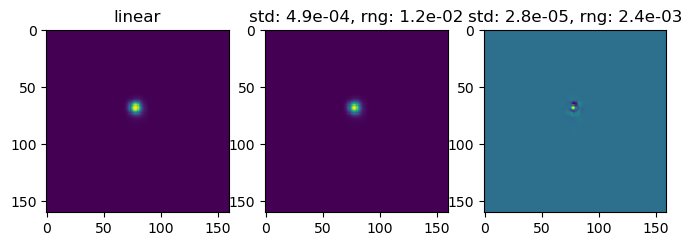

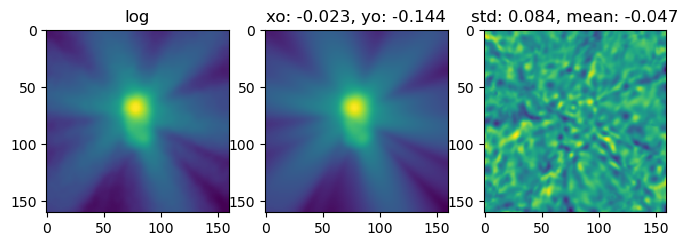

In [108]:
idx = 0
xotest = psfxs[idx]
yotest = psfys[idx]
gt = psfarrs[idx]

xtest = jnp.stack((xpxn, ypxn, 
           jnp.ones_like(xpxn)*psfon.normalize(xotest), 
           jnp.ones_like(ypxn)*psfon.normalize(yotest)), 
           axis=-1).reshape(-1, 4)

pred = jax.vmap(model)(xtest).reshape(psfarrs.shape[1:])
rnpred = pred / pred.sum()
rngt = gt / gt.sum()
diff = rngt - rnpred

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(rnpred, interpolation='nearest')
ax2.imshow(rngt, interpolation='nearest')
ax3.imshow(diff, interpolation='nearest')

ax2.set_title(f'std: {rnpred.std():.1e}, rng: {rnpred.max()-rnpred.min():.1e}')
ax3.set_title(f'std: {diff.std():.1e}, rng: {diff.max()-diff.min():.1e}')

ax1.set_title('linear')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(jnp.log(rnpred), interpolation='nearest')
ax2.imshow(jnp.log(rngt), interpolation='nearest')
ldiff = jnp.log(rngt) - jnp.log(rnpred)
ax3.imshow(ldiff, interpolation='nearest')
ax3.set_title(f'std: {ldiff.std():.2}, mean: {ldiff.mean():.2}')
ax1.set_title('log')
ax2.set_title(f'xo: {xotest:.3f}, yo: {yotest:.3f}')

print('resid std:', diff.std(), 'relative to image:', diff.std()/rngt.std())

resid std: 3.436149e-05 relative to image: 0.068300575


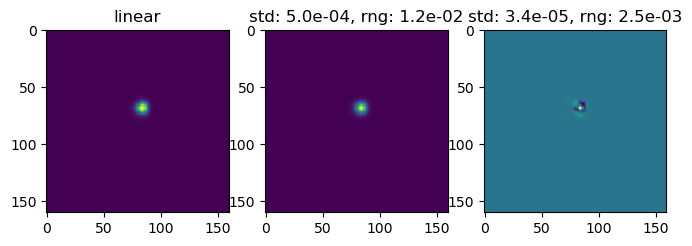

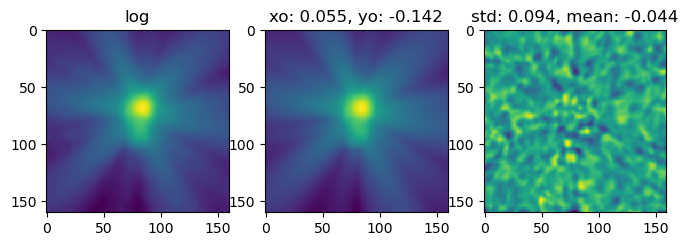

In [109]:
idx = psfxs.size//2
xotest = psfxs[idx]
yotest = psfys[idx]
gt = psfarrs[idx]

xtest = jnp.stack((xpxn, ypxn, 
           jnp.ones_like(xpxn)*psfon.normalize(xotest), 
           jnp.ones_like(ypxn)*psfon.normalize(yotest)), 
           axis=-1).reshape(-1, 4)

pred = jax.vmap(model)(xtest).reshape(psfarrs.shape[1:])
rnpred = pred / pred.sum()
rngt = gt / gt.sum()
diff = rngt - rnpred

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(rnpred, interpolation='nearest')
ax2.imshow(rngt, interpolation='nearest')
ax3.imshow(diff, interpolation='nearest')

ax2.set_title(f'std: {rnpred.std():.1e}, rng: {rnpred.max()-rnpred.min():.1e}')
ax3.set_title(f'std: {diff.std():.1e}, rng: {diff.max()-diff.min():.1e}')

ax1.set_title('linear')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(jnp.log(rnpred), interpolation='nearest')
ax2.imshow(jnp.log(rngt), interpolation='nearest')
ldiff = jnp.log(rngt) - jnp.log(rnpred)
ax3.imshow(ldiff, interpolation='nearest')
ax3.set_title(f'std: {ldiff.std():.2}, mean: {ldiff.mean():.2}')
ax1.set_title('log')
ax2.set_title(f'xo: {xotest:.3f}, yo: {yotest:.3f}')

print('resid std:', diff.std(), 'relative to image:', diff.std()/rngt.std())

In [110]:
vm = jax.jit(jax.vmap(model))
vm(xtest).reshape(psfarrs.shape[1:]).block_until_ready()

%timeit vm(xtest).reshape(psfarrs.shape[1:]).block_until_ready()

311 μs ± 7.32 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


## N-D WIRE

In [41]:
class GaborLayerND(eqx.Module):
    w0: float
    s0: float
    lin1: eqx.nn.Linear
    lin2: eqx.nn.Linear
    lin3: eqx.nn.Linear

    def __init__(self, nin, nout, w0=20, s0=10, rkey=None,trainable0s=True):
        if rkey is None:
            rkey = jax.random.PRNGKey(0)

        rk1, rk2, rk3 = jax.random.split(rkey, 3)
        self.lin1 = eqx.nn.Linear(nin, nout, key=rk1)
        self.lin2 = eqx.nn.Linear(nin, nout, key=rk2)
        self.lin3 = eqx.nn.Linear(nin, nout, key=rk3)

        if trainable0s:
            self.w0 = jnp.array(w0, dtype=jnp.float32)
            self.s0 = jnp.array(s0, dtype=jnp.float32)
        else:
            self.w0 = w0
            self.s0 = s0

    def __call__(self, x):
        x1 = self.lin1(x)
        x2 = self.lin2(x)
        x3 = self.lin3(x)

        return self.nonlinearity(x1, x2, x3)
    
class CosGaborLayerND(GaborLayerND):
    def nonlinearity(self, x1, x2, x3):
        return jnp.cos(self.w0 * x1) * jnp.exp(-(x2 * self.s0)**2 -(x3 * self.s0)**2)
    
class ComplexGaborLayerND(GaborLayerND):
    def nonlinearity(self, x1, x2, x3):
        t1 = x1 * (self.w0 * 1j)
        t2 = jnp.abs(x2 * self.s0)**2
        t3 = jnp.abs(x3 * self.s0)**2
        return jnp.exp(t1-t2-t3)


class PSFWIREND(eqx.Module):
    layers: list

    def __init__(self, n_in_coo,
                       hidden_size=256, 
                       num_hidden_layers=2, 
                       final_activation=jax.nn.sigmoid,
                       rkey=None,
                       complex=False,
                       w0=20, s0=10,
                       trainable_activations=False):
        if rkey is None:
            rkey = jax.random.PRNGKey(0)

        rkeys = jax.random.split(rkey, num_hidden_layers+2)

        if complex:
            layers = [ComplexGaborLayerND(n_in_coo, hidden_size, rkey=rkeys[0],
                                    w0=w0, s0=s0, trainable0s=trainable_activations)]
            for i in range(num_hidden_layers):
                layers.append(ComplexGaborLayerND(hidden_size, hidden_size, rkey=rkeys[i+1],
                                            w0=w0, s0=s0, trainable0s=trainable_activations))

            layers.append(eqx.nn.Linear(hidden_size, 1, key=rkeys[-1]))
            layers.append(jnp.real)
        else:
            layers = [CosGaborLayerND(n_in_coo, hidden_size, rkey=rkeys[0],
                                    w0=w0, s0=s0, trainable0s=trainable_activations)]
            for i in range(num_hidden_layers):
                layers.append(CosGaborLayerND(hidden_size, hidden_size, rkey=rkeys[i+1],
                                            w0=w0, s0=s0, trainable0s=trainable_activations))

            layers.append(eqx.nn.Linear(hidden_size, 1, key=rkeys[-1]))
        layers.append(final_activation)

        self.layers = layers
        
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x.squeeze()  

model = PSFWIREND(n_in_coo=4)
print(model)

x = jax.random.uniform(rkey, (10, 4))
jax.vmap(model)(x)

PSFWIREND(
  layers=[
    CosGaborLayerND(
      w0=20,
      s0=10,
      lin1=Linear(
        weight=f32[256,4],
        bias=f32[256],
        in_features=4,
        out_features=256,
        use_bias=True
      ),
      lin2=Linear(
        weight=f32[256,4],
        bias=f32[256],
        in_features=4,
        out_features=256,
        use_bias=True
      ),
      lin3=Linear(
        weight=f32[256,4],
        bias=f32[256],
        in_features=4,
        out_features=256,
        use_bias=True
      )
    ),
    CosGaborLayerND(
      w0=20,
      s0=10,
      lin1=Linear(
        weight=f32[256,256],
        bias=f32[256],
        in_features=256,
        out_features=256,
        use_bias=True
      ),
      lin2=Linear(
        weight=f32[256,256],
        bias=f32[256],
        in_features=256,
        out_features=256,
        use_bias=True
      ),
      lin3=Linear(
        weight=f32[256,256],
        bias=f32[256],
        in_features=256,
        out_features=256,
   

Array([0.5067287 , 0.5173181 , 0.51223785, 0.49655986, 0.5104151 ,
       0.5278603 , 0.47451505, 0.5294091 , 0.5239821 , 0.49860618],      dtype=float32)

  0%|          | 0/10000 [00:00<?, ?it/s]

resid std: 2.2417724e-05 relative to image: 0.044559866


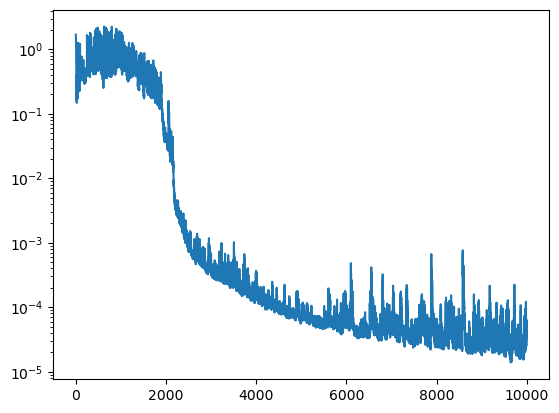

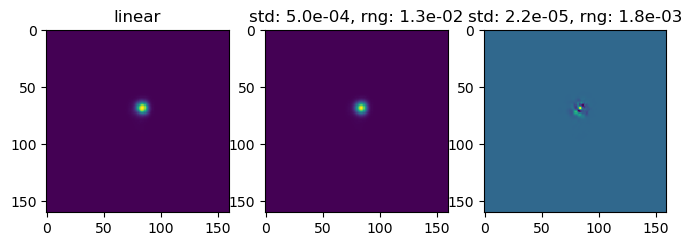

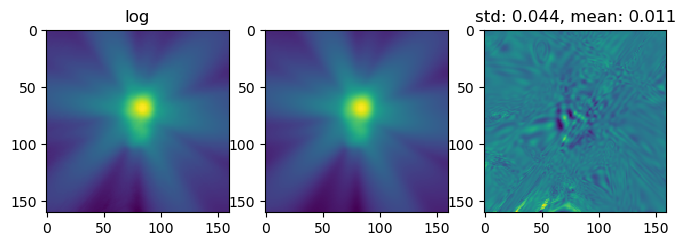

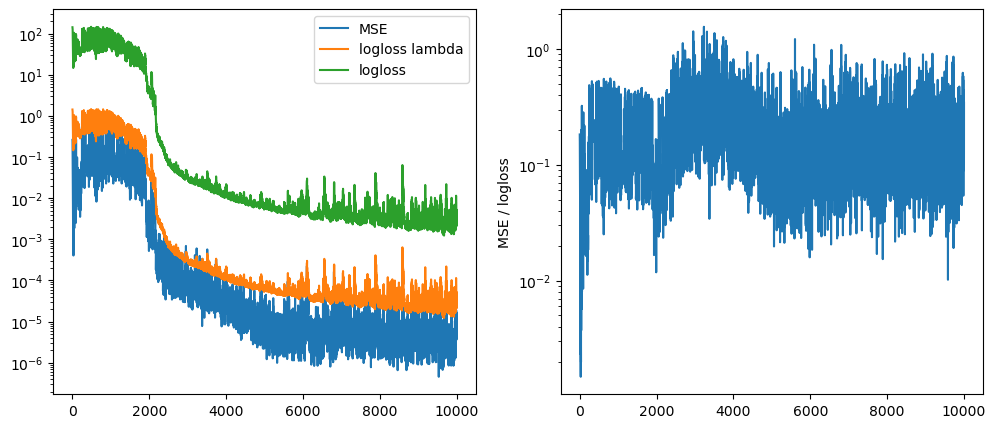

In [49]:
LEARNING_RATE = 1e-3
EPOCHS = 10000
BATCH_SIZE = 2048*2

LOSS_LOG_LAMBDA = 1e-2

rkey = jax.random.PRNGKey(43)

psf = psfarrs[512] # psf is (160, 160)

xpx, ypx = jnp.indices(psfarrs.shape[1:])

xs = jnp.stack((xpx.ravel(), ypx.ravel()), axis=-1).astype(float)
xnorm = CoordinateNormalizer(xs)
xs = xnorm.normalize(xs)
ys = psf.ravel()/psf.max()


rkey, subkey = jax.random.split(rkey)
model = PSFWIREND(n_in_coo=2, complex=True, w0=10, s0=20, rkey=subkey)

optimizer = optax.adam(learning_rate=LEARNING_RATE)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

mselosses = jnp.ones((EPOCHS,)) * jnp.nan
losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    mselosses = mselosses.at[i].set(mse_loss_fn(model, xi, yi))
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update, losslamb=LOSS_LOG_LAMBDA)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)

pred = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])
rnpred = pred / pred.sum()
rnpsf = psf / psf.sum()
diff = rnpsf - rnpred

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(rnpred, interpolation='nearest')
ax2.imshow(rnpsf, interpolation='nearest')
ax3.imshow(diff, interpolation='nearest')

ax2.set_title(f'std: {rnpred.std():.1e}, rng: {rnpred.max()-rnpred.min():.1e}')
ax3.set_title(f'std: {diff.std():.1e}, rng: {diff.max()-diff.min():.1e}')

ax1.set_title('linear')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(jnp.log(rnpred), interpolation='nearest')
ax2.imshow(jnp.log(rnpsf), interpolation='nearest')
ldiff = jnp.log(rnpsf) - jnp.log(rnpred)
ax3.imshow(ldiff, interpolation='nearest')
ax3.set_title(f'std: {ldiff.std():.2}, mean: {ldiff.mean():.2}')
ax1.set_title('log')

print('resid std:', diff.std(), 'relative to image:', diff.std()/rnpsf.std())

# compare the different loss function compnents
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
loglossesl = losses - mselosses
loglosses = loglossesl / LOSS_LOG_LAMBDA
ax1.semilogy(mselosses, label='MSE')
ax1.semilogy(loglossesl, label='logloss lambda')
ax1.semilogy(loglosses, label='logloss')
ax1.legend(loc=0)

ax2.semilogy(mselosses/loglossesl)
ax2.set_ylabel('MSE / logloss');

y1 shape: (160, 160, 1)


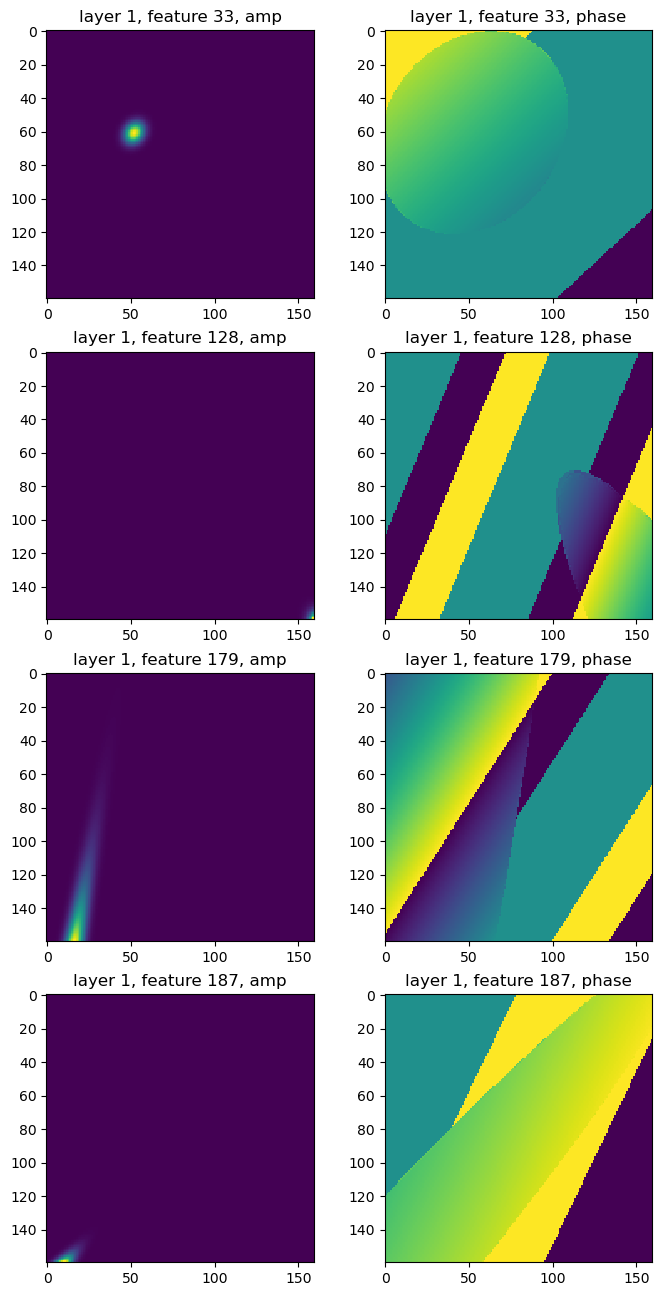

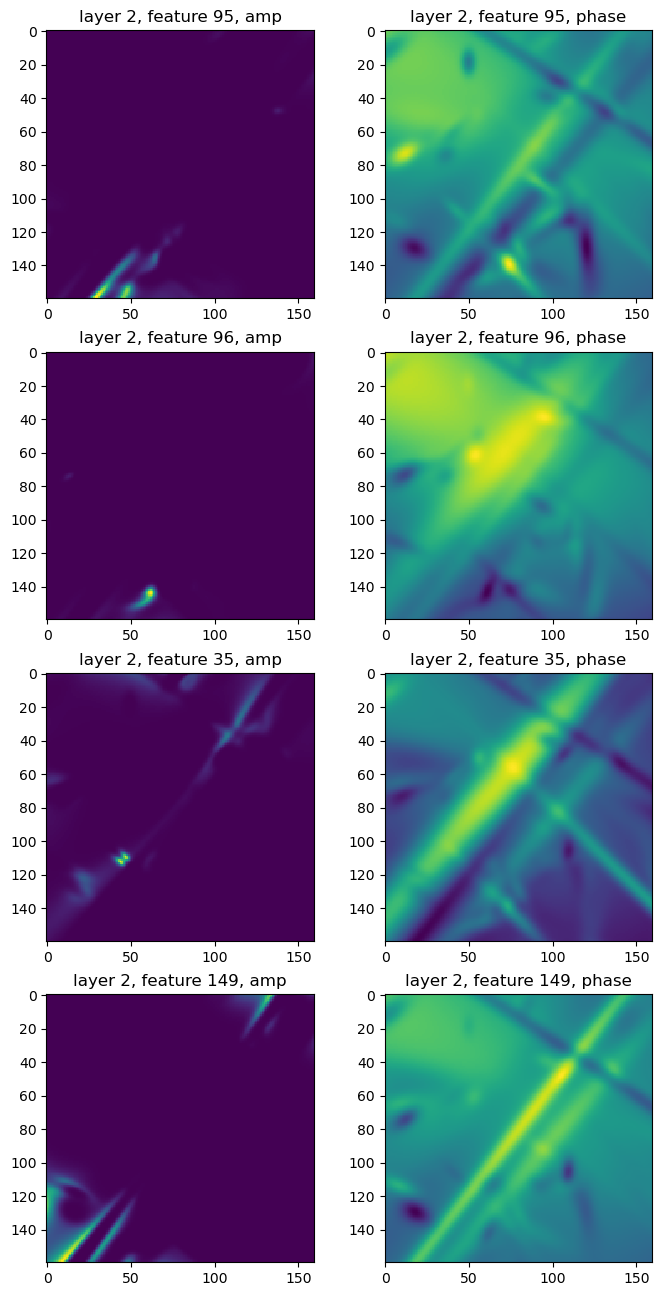

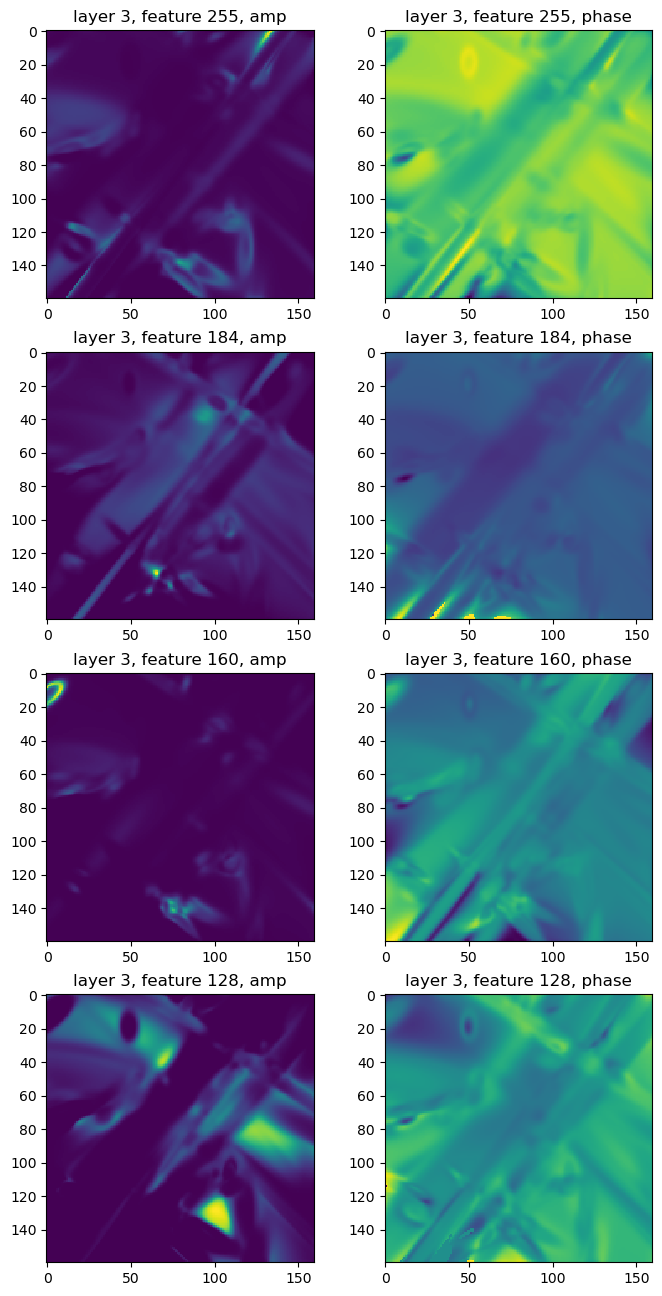

<Figure size 640x480 with 0 Axes>

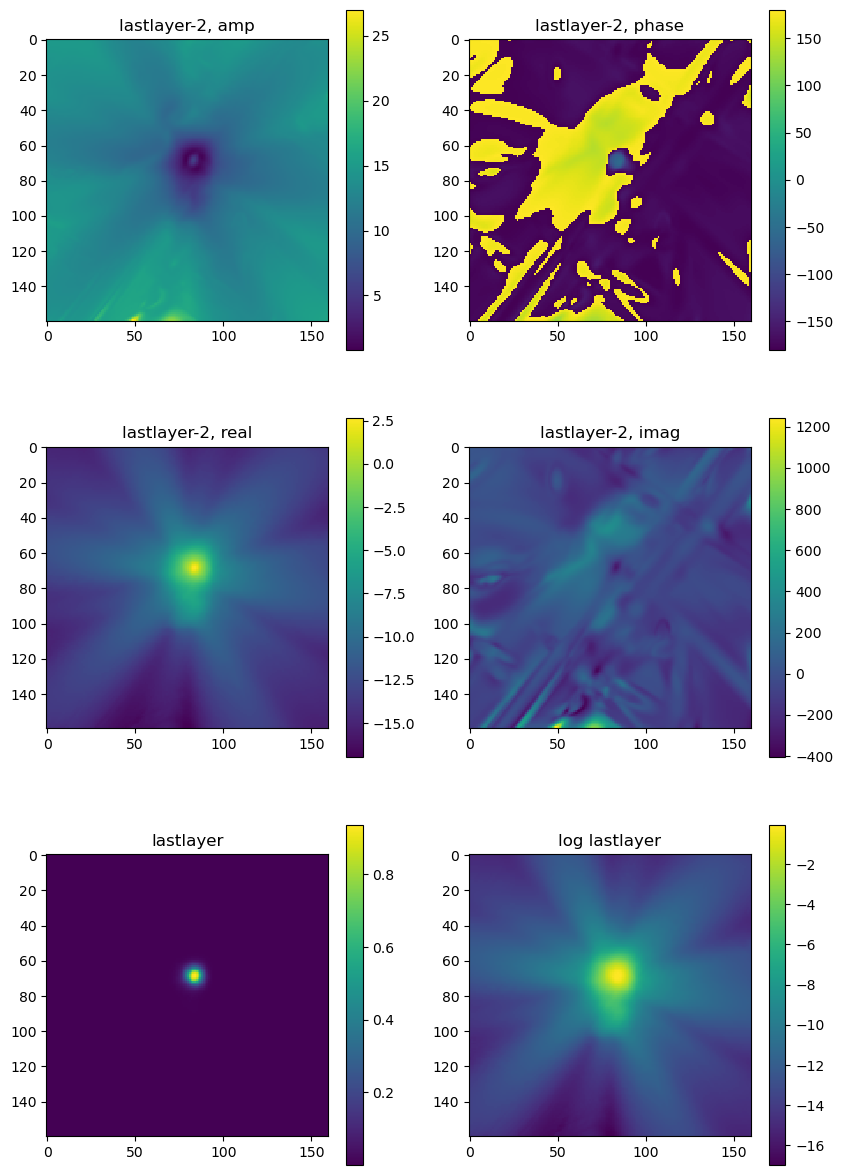

In [50]:
def viz_layers2(model, xs, axlen=4, figsize=(8, 16)):
    nl = len(model.layers)
    def eval_layers(x, n):
        for i in range(n):
            x = model.layers[i](x)
        return x
    
    for n in range(1, nl-2):
        yl =  jax.vmap(partial(eval_layers, n=n))(xs).reshape(psfarrs.shape[1:] + (-1,))
        _, axs = plt.subplots(axlen, 2, figsize=figsize)
        idxs = np.random.choice(np.arange(yl.shape[-1]), size=axlen, replace=False)
        for axrow, idx in zip(axs, idxs):
            axrow[0].imshow(jnp.abs(yl[..., idx]), interpolation='nearest')
            axrow[0].set_title(f'layer {n}, feature {idx}, amp')
            axrow[1].imshow(jnp.angle(yl[..., idx]), interpolation='nearest')
            axrow[1].set_title(f'layer {n}, feature {idx}, phase')


    y1 = jax.vmap(partial(eval_layers, n=nl-2))(xs).reshape(psfarrs.shape[1:] + (-1,))
    print('y1 shape:', y1.shape)

    plt.figure()
    _, axs = plt.subplots(3, 2, figsize=(10, 15))
    axs = axs.ravel()

    cb = axs[0].imshow(jnp.abs(y1[..., 0]), interpolation='nearest')
    plt.colorbar(cb, ax=axs[0])
    axs[0].set_title('lastlayer-2, amp')
    cb = axs[1].imshow(jnp.angle(y1[..., 0])*180/np.pi, interpolation='nearest')
    plt.colorbar(cb, ax=axs[1])
    axs[1].set_title('lastlayer-2, phase')

    cb = axs[2].imshow(jnp.real(y1[..., 0]), interpolation='nearest')
    plt.colorbar(cb, ax=axs[2])
    axs[2].set_title('lastlayer-2, real')
    cb = axs[3].imshow(jnp.imag(y1[..., 0])*180/np.pi, interpolation='nearest')
    plt.colorbar(cb, ax=axs[3])
    axs[3].set_title('lastlayer-2, imag')


    y2 = jax.vmap(partial(eval_layers, n=nl-1))(xs).reshape(psfarrs.shape[1:] + (-1,))
    y3 = jax.vmap(partial(eval_layers, n=nl))(xs).reshape(psfarrs.shape[1:] + (-1,))
    cb = axs[4].imshow(y3[..., 0], interpolation='nearest')
    plt.colorbar(cb, ax=axs[4])
    axs[4].set_title('lastlayer')
    cb = axs[5].imshow(jnp.log(y3[..., 0]), interpolation='nearest')
    plt.colorbar(cb, ax=axs[5])
    axs[5].set_title('log lastlayer')
             
viz_layers2(model, xs)


## Sin or sigmoid last activation?

Sigmoid/fiducial

  0%|          | 0/10000 [00:00<?, ?it/s]

resid std: 3.5739264e-05 relative to image: 0.071039185


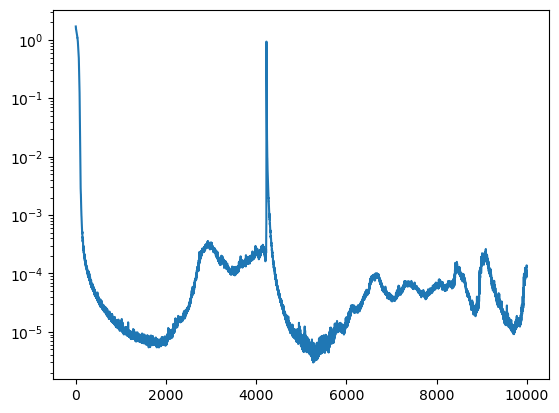

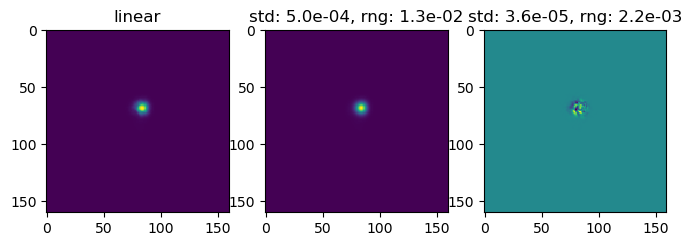

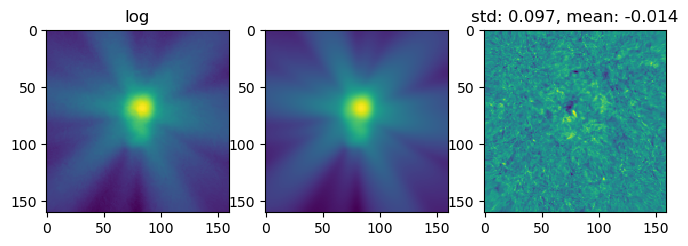

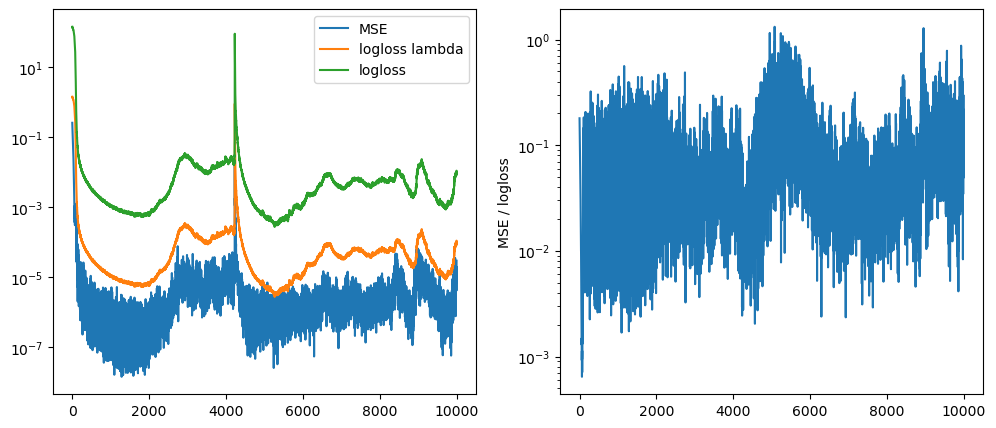

In [131]:
LEARNING_RATE = 1e-3
EPOCHS = 10000
BATCH_SIZE = 2048

LOSS_LOG_LAMBDA = 1e-2

rkey = jax.random.PRNGKey(43)

psf = psfarrs[512] # psf is (160, 160)

xpx, ypx = jnp.indices(psfarrs.shape[1:])

xs = jnp.stack((xpx.ravel(), ypx.ravel()), axis=-1).astype(float)
xnorm = CoordinateNormalizer(xs)
xs = xnorm.normalize(xs)
ys = psf.ravel()/psf.max()


rkey, subkey = jax.random.split(rkey)
model = PSFWIRE1D(n_in_coo=2, trainable_activations=False, rkey=subkey)

optimizer = optax.adam(learning_rate=LEARNING_RATE)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

mselosses = jnp.ones((EPOCHS,)) * jnp.nan
losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    mselosses = mselosses.at[i].set(mse_loss_fn(model, xi, yi))
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update, losslamb=LOSS_LOG_LAMBDA)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)

pred = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])
rnpred = pred / pred.sum()
rnpsf = psf / psf.sum()
diff = rnpsf - rnpred

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(rnpred, interpolation='nearest')
ax2.imshow(rnpsf, interpolation='nearest')
ax3.imshow(diff, interpolation='nearest')

ax2.set_title(f'std: {rnpred.std():.1e}, rng: {rnpred.max()-rnpred.min():.1e}')
ax3.set_title(f'std: {diff.std():.1e}, rng: {diff.max()-diff.min():.1e}')

ax1.set_title('linear')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(jnp.log(rnpred), interpolation='nearest')
ax2.imshow(jnp.log(rnpsf), interpolation='nearest')
ldiff = jnp.log(rnpsf) - jnp.log(rnpred)
ax3.imshow(ldiff, interpolation='nearest')
ax3.set_title(f'std: {ldiff.std():.2}, mean: {ldiff.mean():.2}')
ax1.set_title('log')

print('resid std:', diff.std(), 'relative to image:', diff.std()/rnpsf.std())

# compare the different loss function compnents
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
loglossesl = losses - mselosses
loglosses = loglossesl / LOSS_LOG_LAMBDA
ax1.semilogy(mselosses, label='MSE')
ax1.semilogy(loglossesl, label='logloss lambda')
ax1.semilogy(loglosses, label='logloss')
ax1.legend(loc=0)

ax2.semilogy(mselosses/loglossesl)
ax2.set_ylabel('MSE / logloss');

tanh

  0%|          | 0/10000 [00:00<?, ?it/s]

resid std: 2.3910372e-05 relative to image: 0.047526814


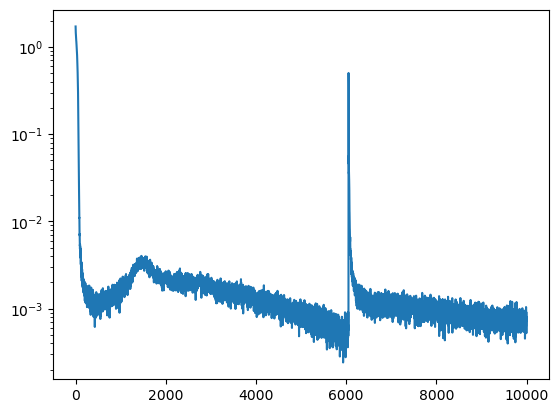

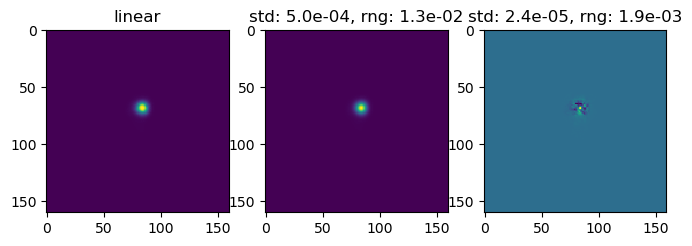

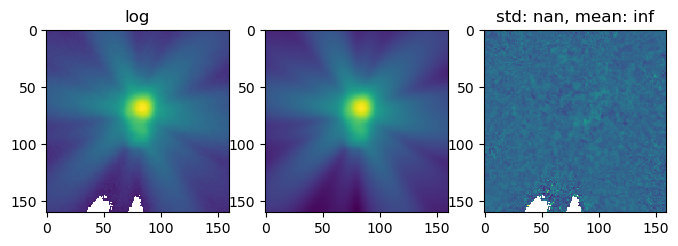

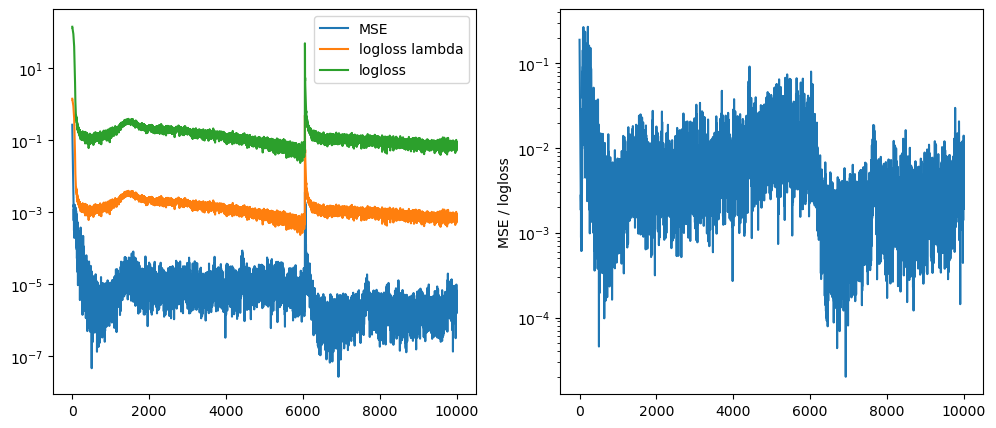

In [162]:
LEARNING_RATE = 1e-3
EPOCHS = 10000
BATCH_SIZE = 2048

LOSS_LOG_LAMBDA = 1e-2

rkey = jax.random.PRNGKey(43)

psf = psfarrs[512] # psf is (160, 160)

xpx, ypx = jnp.indices(psfarrs.shape[1:])

xs = jnp.stack((xpx.ravel(), ypx.ravel()), axis=-1).astype(float)
xnorm = CoordinateNormalizer(xs)
xs = xnorm.normalize(xs)
ys = psf.ravel()/psf.max()


rkey, subkey = jax.random.split(rkey)
model = PSFWIRE1D(n_in_coo=2, trainable_activations=False, rkey=subkey, final_activation=lambda x:(jnp.tanh(x)+1.)/2.)

optimizer = optax.adam(learning_rate=LEARNING_RATE)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

mselosses = jnp.ones((EPOCHS,)) * jnp.nan
losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    mselosses = mselosses.at[i].set(mse_loss_fn(model, xi, yi))
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update, losslamb=LOSS_LOG_LAMBDA)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)

pred = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])
rnpred = pred / pred.sum()
rnpsf = psf / psf.sum()
diff = rnpsf - rnpred

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(rnpred, interpolation='nearest')
ax2.imshow(rnpsf, interpolation='nearest')
ax3.imshow(diff, interpolation='nearest')

ax2.set_title(f'std: {rnpred.std():.1e}, rng: {rnpred.max()-rnpred.min():.1e}')
ax3.set_title(f'std: {diff.std():.1e}, rng: {diff.max()-diff.min():.1e}')

ax1.set_title('linear')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(jnp.log(rnpred), interpolation='nearest')
ax2.imshow(jnp.log(rnpsf), interpolation='nearest')
ldiff = jnp.log(rnpsf) - jnp.log(rnpred)
ax3.imshow(ldiff, interpolation='nearest')
ax3.set_title(f'std: {ldiff.std():.2}, mean: {ldiff.mean():.2}')
ax1.set_title('log')

print('resid std:', diff.std(), 'relative to image:', diff.std()/rnpsf.std())

# compare the different loss function compnents
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
loglossesl = losses - mselosses
loglosses = loglossesl / LOSS_LOG_LAMBDA
ax1.semilogy(mselosses, label='MSE')
ax1.semilogy(loglossesl, label='logloss lambda')
ax1.semilogy(loglosses, label='logloss')
ax1.legend(loc=0)

ax2.semilogy(mselosses/loglossesl)
ax2.set_ylabel('MSE / logloss');

arctan

  0%|          | 0/10000 [00:00<?, ?it/s]

resid std: 0.00034976058 relative to image: 0.69522154


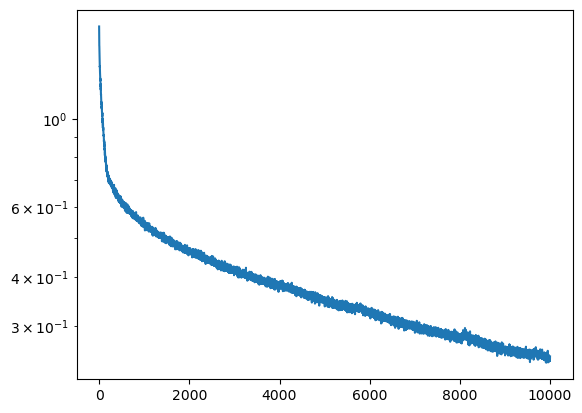

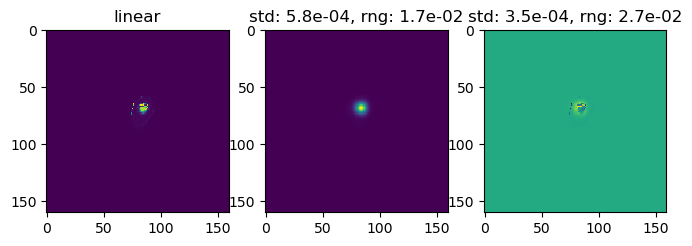

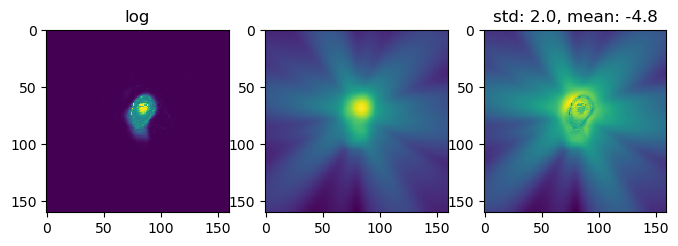

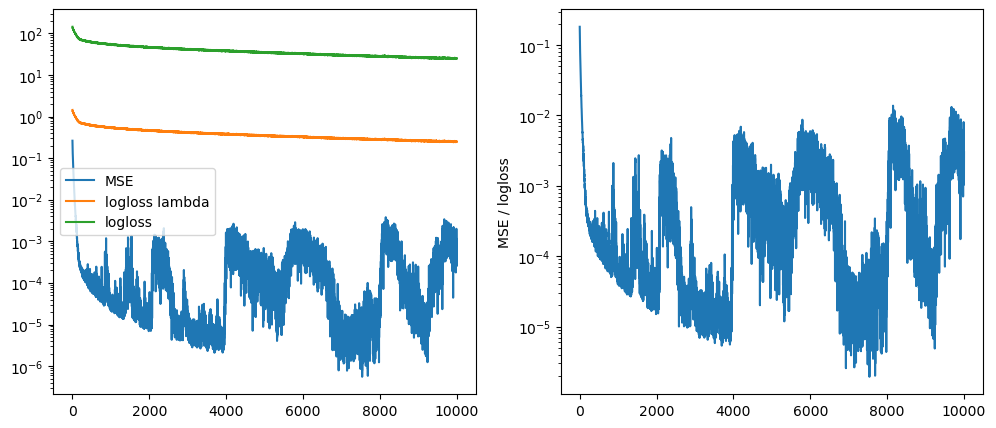

In [158]:
LEARNING_RATE = 1e-3
EPOCHS = 10000
BATCH_SIZE = 2048

LOSS_LOG_LAMBDA = 1e-2

rkey = jax.random.PRNGKey(43)

psf = psfarrs[512] # psf is (160, 160)

xpx, ypx = jnp.indices(psfarrs.shape[1:])

xs = jnp.stack((xpx.ravel(), ypx.ravel()), axis=-1).astype(float)
xnorm = CoordinateNormalizer(xs)
xs = xnorm.normalize(xs)
ys = psf.ravel()/psf.max()


rkey, subkey = jax.random.split(rkey)
model = PSFWIRE1D(n_in_coo=2, trainable_activations=False, rkey=subkey, final_activation=lambda x:jnp.arctan(x)/jnp.pi + 0.5)

optimizer = optax.adam(learning_rate=LEARNING_RATE)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

mselosses = jnp.ones((EPOCHS,)) * jnp.nan
losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    mselosses = mselosses.at[i].set(mse_loss_fn(model, xi, yi))
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update, losslamb=LOSS_LOG_LAMBDA)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)

pred = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])
rnpred = pred / pred.sum()
rnpsf = psf / psf.sum()
diff = rnpsf - rnpred

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(rnpred, interpolation='nearest')
ax2.imshow(rnpsf, interpolation='nearest')
ax3.imshow(diff, interpolation='nearest')

ax2.set_title(f'std: {rnpred.std():.1e}, rng: {rnpred.max()-rnpred.min():.1e}')
ax3.set_title(f'std: {diff.std():.1e}, rng: {diff.max()-diff.min():.1e}')

ax1.set_title('linear')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(jnp.log(rnpred), interpolation='nearest')
ax2.imshow(jnp.log(rnpsf), interpolation='nearest')
ldiff = jnp.log(rnpsf) - jnp.log(rnpred)
ax3.imshow(ldiff, interpolation='nearest')
ax3.set_title(f'std: {ldiff.std():.2}, mean: {ldiff.mean():.2}')
ax1.set_title('log')

print('resid std:', diff.std(), 'relative to image:', diff.std()/rnpsf.std())

# compare the different loss function compnents
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
loglossesl = losses - mselosses
loglosses = loglossesl / LOSS_LOG_LAMBDA
ax1.semilogy(mselosses, label='MSE')
ax1.semilogy(loglossesl, label='logloss lambda')
ax1.semilogy(loglosses, label='logloss')
ax1.legend(loc=0)

ax2.semilogy(mselosses/loglossesl)
ax2.set_ylabel('MSE / logloss');

sin

  0%|          | 0/10000 [00:00<?, ?it/s]

resid std: 0.00050450256 relative to image: 1.0028033


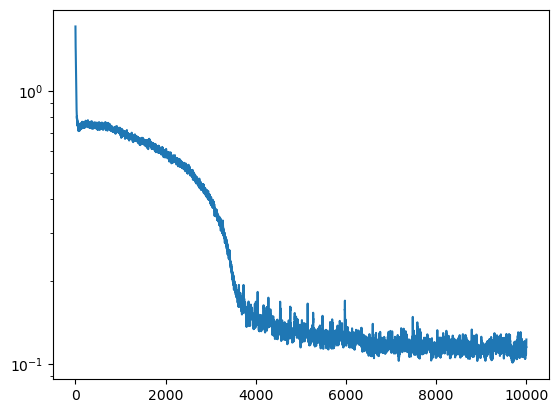

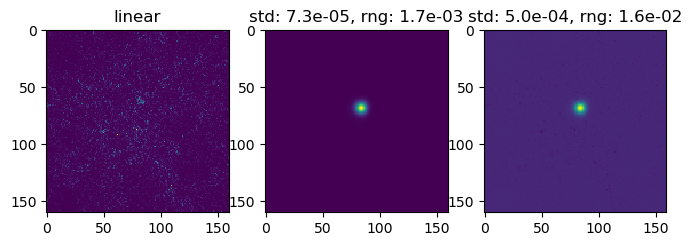

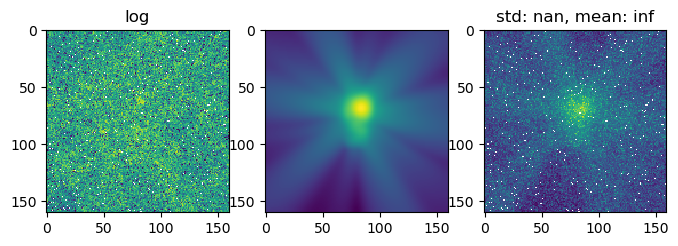

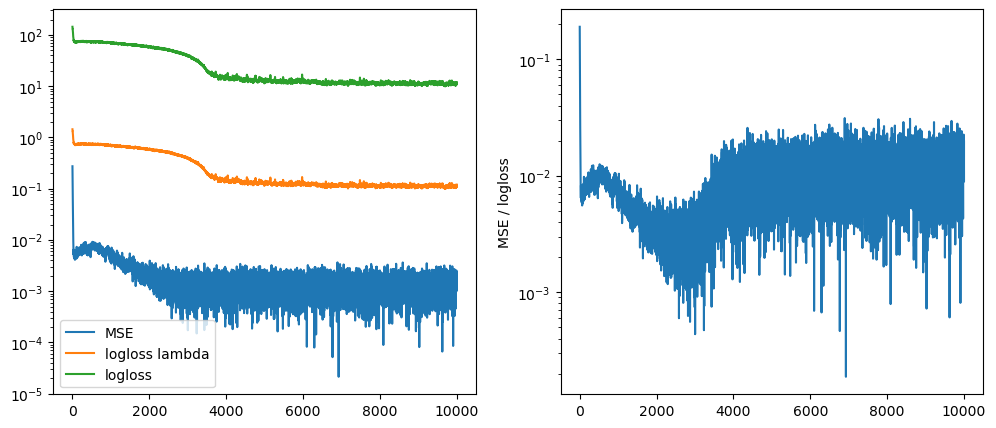

In [163]:
LEARNING_RATE = 1e-3
EPOCHS = 10000
BATCH_SIZE = 2048

LOSS_LOG_LAMBDA = 1e-2

rkey = jax.random.PRNGKey(43)

psf = psfarrs[512] # psf is (160, 160)

xpx, ypx = jnp.indices(psfarrs.shape[1:])

xs = jnp.stack((xpx.ravel(), ypx.ravel()), axis=-1).astype(float)
xnorm = CoordinateNormalizer(xs)
xs = xnorm.normalize(xs)
ys = psf.ravel()/psf.max()


rkey, subkey = jax.random.split(rkey)
model = PSFWIRE1D(n_in_coo=2, trainable_activations=False, rkey=subkey, final_activation=lambda x:(jnp.sin(x)+1.)/2.)

optimizer = optax.adam(learning_rate=LEARNING_RATE)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

mselosses = jnp.ones((EPOCHS,)) * jnp.nan
losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    mselosses = mselosses.at[i].set(mse_loss_fn(model, xi, yi))
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update, losslamb=LOSS_LOG_LAMBDA)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)

pred = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])
rnpred = pred / pred.sum()
rnpsf = psf / psf.sum()
diff = rnpsf - rnpred

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(rnpred, interpolation='nearest')
ax2.imshow(rnpsf, interpolation='nearest')
ax3.imshow(diff, interpolation='nearest')

ax2.set_title(f'std: {rnpred.std():.1e}, rng: {rnpred.max()-rnpred.min():.1e}')
ax3.set_title(f'std: {diff.std():.1e}, rng: {diff.max()-diff.min():.1e}')

ax1.set_title('linear')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(jnp.log(rnpred), interpolation='nearest')
ax2.imshow(jnp.log(rnpsf), interpolation='nearest')
ldiff = jnp.log(rnpsf) - jnp.log(rnpred)
ax3.imshow(ldiff, interpolation='nearest')
ax3.set_title(f'std: {ldiff.std():.2}, mean: {ldiff.mean():.2}')
ax1.set_title('log')

print('resid std:', diff.std(), 'relative to image:', diff.std()/rnpsf.std())

# compare the different loss function compnents
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
loglossesl = losses - mselosses
loglosses = loglossesl / LOSS_LOG_LAMBDA
ax1.semilogy(mselosses, label='MSE')
ax1.semilogy(loglossesl, label='logloss lambda')
ax1.semilogy(loglosses, label='logloss')
ax1.legend(loc=0)

ax2.semilogy(mselosses/loglossesl)
ax2.set_ylabel('MSE / logloss');

## Trainable gabor parameters or not?

  0%|          | 0/15000 [00:00<?, ?it/s]

resid std: 5.5213994e-05 relative to image: 0.10974924


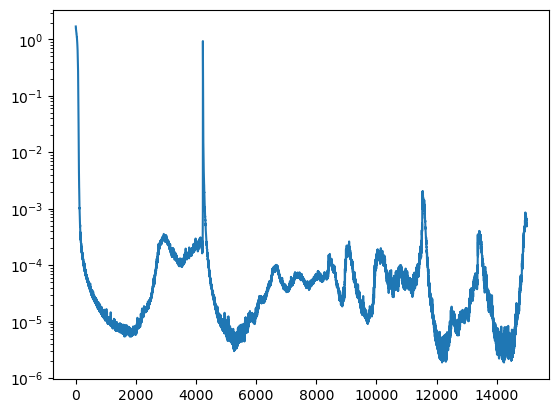

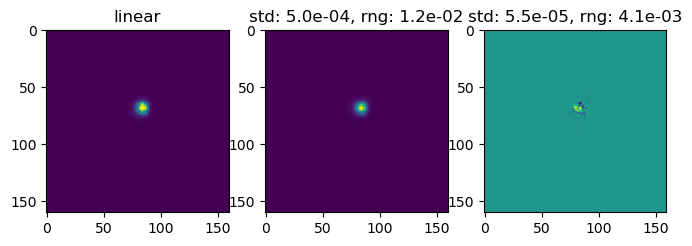

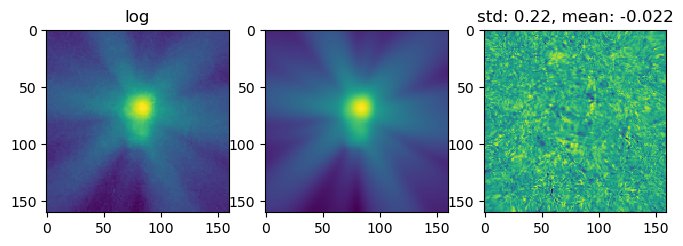

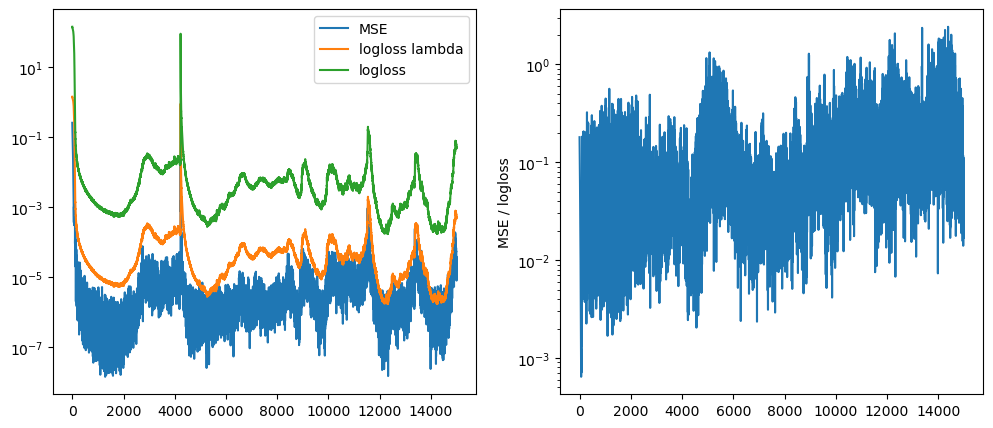

In [ ]:
LEARNING_RATE = 1e-3
EPOCHS = 15000
BATCH_SIZE = 2048

LOSS_LOG_LAMBDA = 1e-2

rkey = jax.random.PRNGKey(43)

psf = psfarrs[512] # psf is (160, 160)

xpx, ypx = jnp.indices(psfarrs.shape[1:])

xs = jnp.stack((xpx.ravel(), ypx.ravel()), axis=-1).astype(float)
xnorm = CoordinateNormalizer(xs)
xs = xnorm.normalize(xs)
ys = psf.ravel()/psf.max()


rkey, subkey = jax.random.split(rkey)
model = PSFWIRE1D(n_in_coo=2, trainable_activations=False, rkey=subkey)

optimizer = optax.adam(learning_rate=LEARNING_RATE)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

mselosses = jnp.ones((EPOCHS,)) * jnp.nan
losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    mselosses = mselosses.at[i].set(mse_loss_fn(model, xi, yi))
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update, losslamb=LOSS_LOG_LAMBDA)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)

pred = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])
rnpred = pred / pred.sum()
rnpsf = psf / psf.sum()
diff = rnpsf - rnpred

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(rnpred, interpolation='nearest')
ax2.imshow(rnpsf, interpolation='nearest')
ax3.imshow(diff, interpolation='nearest')

ax2.set_title(f'std: {rnpred.std():.1e}, rng: {rnpred.max()-rnpred.min():.1e}')
ax3.set_title(f'std: {diff.std():.1e}, rng: {diff.max()-diff.min():.1e}')

ax1.set_title('linear')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(jnp.log(rnpred), interpolation='nearest')
ax2.imshow(jnp.log(rnpsf), interpolation='nearest')
ldiff = jnp.log(rnpsf) - jnp.log(rnpred)
ax3.imshow(ldiff, interpolation='nearest')
ax3.set_title(f'std: {ldiff.std():.2}, mean: {ldiff.mean():.2}')
ax1.set_title('log')

print('resid std:', diff.std(), 'relative to image:', diff.std()/rnpsf.std())

# compare the different loss function compnents
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
loglossesl = losses - mselosses
loglosses = loglossesl / LOSS_LOG_LAMBDA
ax1.semilogy(mselosses, label='MSE')
ax1.semilogy(loglossesl, label='logloss lambda')
ax1.semilogy(loglosses, label='logloss')
ax1.legend(loc=0)

ax2.semilogy(mselosses/loglossesl)
ax2.set_ylabel('MSE / logloss');

  0%|          | 0/15000 [00:00<?, ?it/s]

resid std: 1.1713416e-05 relative to image: 0.023282839


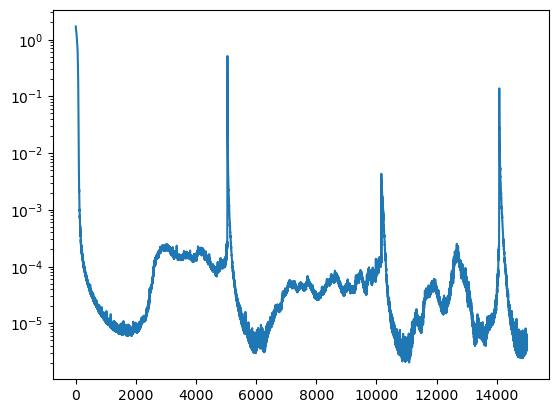

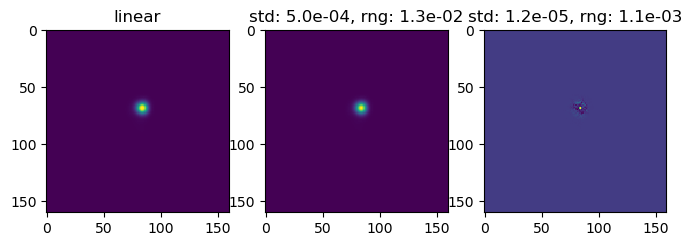

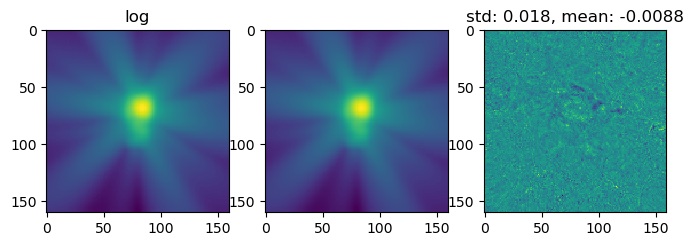

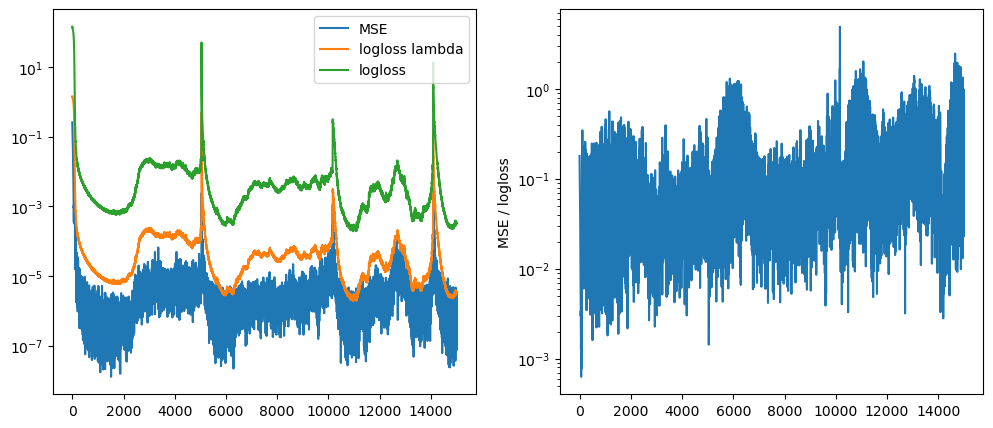

In [ ]:
LEARNING_RATE = 1e-3
EPOCHS = 15000
BATCH_SIZE = 2048

LOSS_LOG_LAMBDA = 1e-2

rkey = jax.random.PRNGKey(43)

psf = psfarrs[512] # psf is (160, 160)

xpx, ypx = jnp.indices(psfarrs.shape[1:])

xs = jnp.stack((xpx.ravel(), ypx.ravel()), axis=-1).astype(float)
xnorm = CoordinateNormalizer(xs)
xs = xnorm.normalize(xs)
ys = psf.ravel()/psf.max()

rkey, subkey = jax.random.split(rkey)
model = PSFWIRE1D(n_in_coo=2, trainable_activations=True, rkey=subkey)

optimizer = optax.adam(learning_rate=LEARNING_RATE)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

mselosses = jnp.ones((EPOCHS,)) * jnp.nan
losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    mselosses = mselosses.at[i].set(mse_loss_fn(model, xi, yi))
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update, losslamb=LOSS_LOG_LAMBDA)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


pred = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])
rnpred = pred / pred.sum()
rnpsf = psf / psf.sum()
diff = rnpsf - rnpred

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(rnpred, interpolation='nearest')
ax2.imshow(rnpsf, interpolation='nearest')
ax3.imshow(diff, interpolation='nearest')

ax2.set_title(f'std: {rnpred.std():.1e}, rng: {rnpred.max()-rnpred.min():.1e}')
ax3.set_title(f'std: {diff.std():.1e}, rng: {diff.max()-diff.min():.1e}')

ax1.set_title('linear')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(jnp.log(rnpred), interpolation='nearest')
ax2.imshow(jnp.log(rnpsf), interpolation='nearest')
ldiff = jnp.log(rnpsf) - jnp.log(rnpred)
ax3.imshow(ldiff, interpolation='nearest')
ax3.set_title(f'std: {ldiff.std():.2}, mean: {ldiff.mean():.2}')
ax1.set_title('log')

print('resid std:', diff.std(), 'relative to image:', diff.std()/rnpsf.std())

# compare the different loss function compnents
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
loglossesl = losses - mselosses
loglosses = loglossesl / LOSS_LOG_LAMBDA
ax1.semilogy(mselosses, label='MSE')
ax1.semilogy(loglossesl, label='logloss lambda')
ax1.semilogy(loglosses, label='logloss')
ax1.legend(loc=0)

ax2.semilogy(mselosses/loglossesl)
ax2.set_ylabel('MSE / logloss');

Might matter in some cases, but not in the default